<b><u>DL PROJECT</u></b>

**Setup and Import**

In [3]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

np.random.seed(42)

**Data Loading**

In [8]:
df = sns.load_dataset('titanic')

print(df.shape)
df.head()

(891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


**Task 1: Exploratory Data Analysis**

In [9]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [10]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [11]:
df.shape

(891, 15)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [13]:
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [14]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


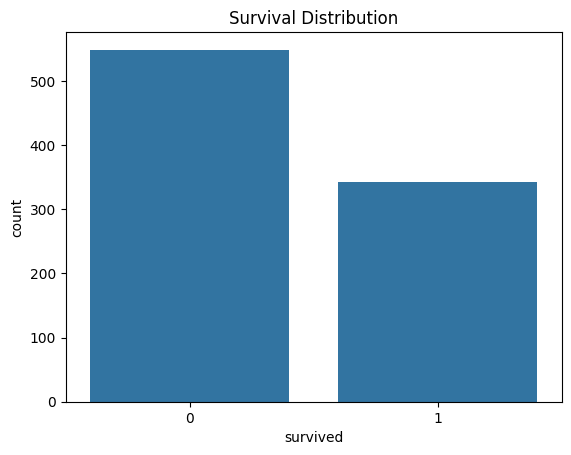

In [15]:
sns.countplot(x='survived', data=df)
plt.title("Survival Distribution")
plt.show()

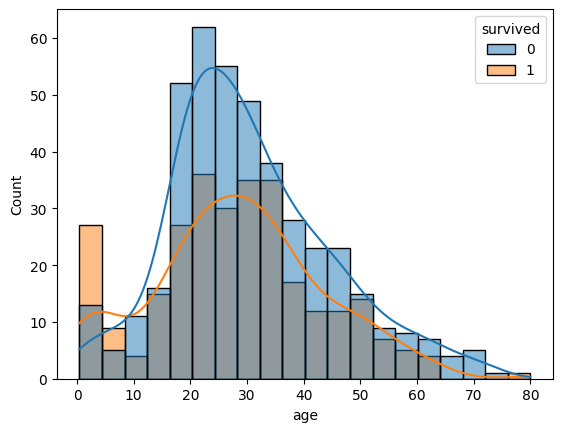

In [17]:
sns.histplot(data=df, x='age', hue='survived', kde=True)
plt.show()

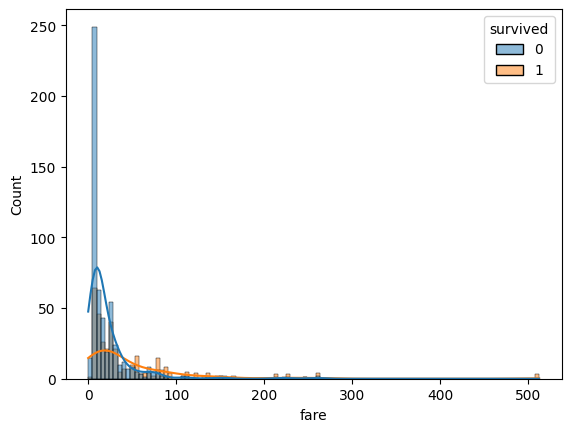

In [18]:
sns.histplot(data=df, x='fare', hue='survived', kde=True)
plt.show()

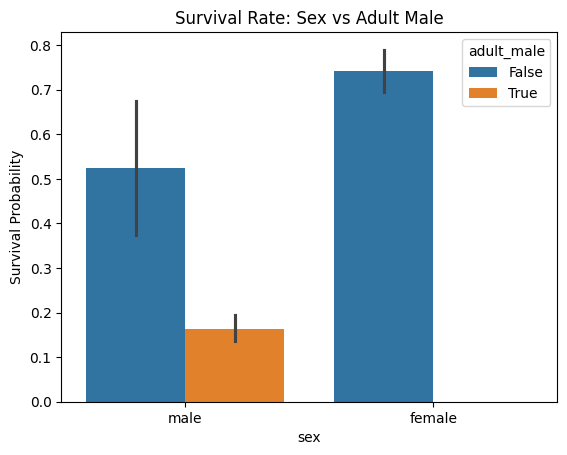

In [30]:
sns.barplot(data=df, x='sex', y='survived', hue='adult_male')
plt.title('Survival Rate: Sex vs Adult Male')
plt.ylabel('Survival Probability')
plt.show()

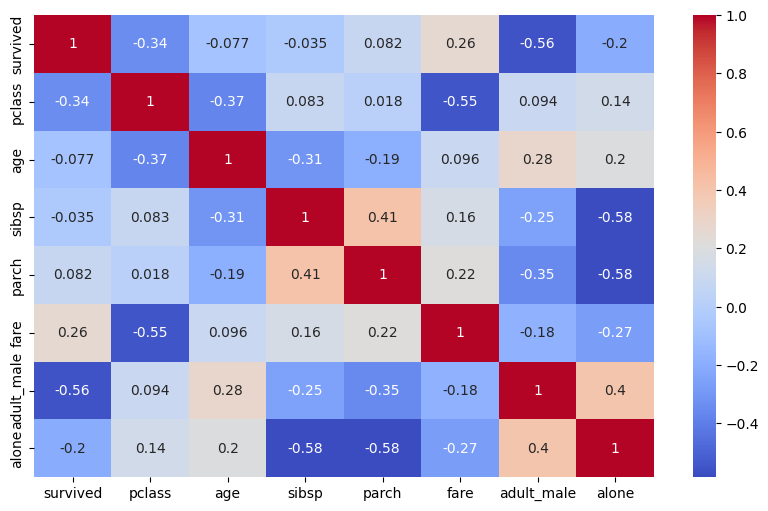

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

1. Most people are not survived as people who survived are above 300 and who didn't survive are above 500.
2. Survival Rate of female is high.
3. Adult Male has less survival rate than children.

**Task 2: Data Preprocessing**

In [35]:
df = df.drop(['deck','embark_town','alive','who','class'], axis=1)

In [36]:
df['age'].fillna(df['age'].median(), inplace=True)
df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_15584\3727767796.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['age'].fillna(df['age'].median(), inplace=True)
C:\Users\Administrator\AppData\Local\Temp\ipykernel_15584\3727767796.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves a

In [37]:
df = df.dropna()

In [38]:
df = pd.get_dummies(df, columns=['sex','embarked'], drop_first=True)


In [39]:
X = df.drop('survived', axis=1)
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [40]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

**Task 3: Train ML Models**

In [41]:
def evaluate_model(model, X_train, X_test, y_train, y_test, name):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    print(f"\n{name}")
    print("Train Accuracy:", model.score(X_train, y_train))
    print("Test Accuracy:", model.score(X_test, y_test))
    
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()


Logistic Regression
Train Accuracy: 0.8230337078651685
Test Accuracy: 0.8379888268156425

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



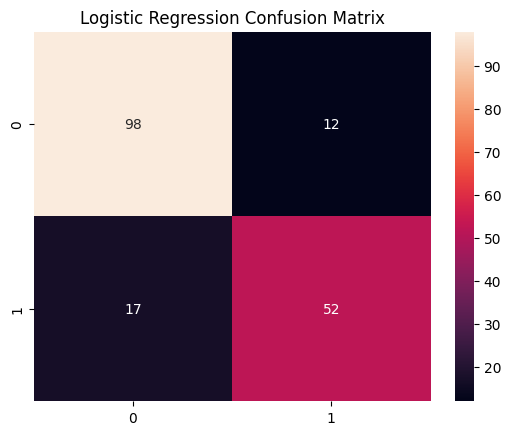

In [42]:
lr = LogisticRegression()
evaluate_model(lr, X_train, X_test, y_train, y_test, "Logistic Regression")


Random Forest
Train Accuracy: 0.9817415730337079
Test Accuracy: 0.8379888268156425

Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179



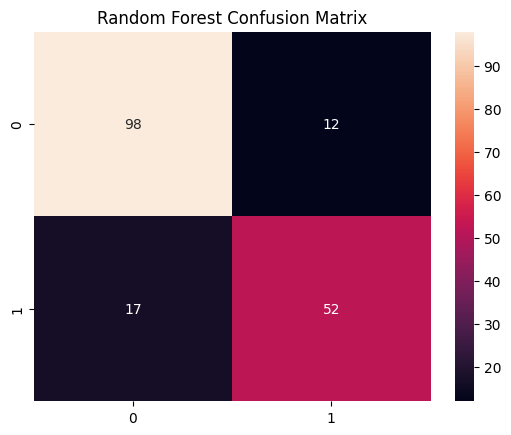

In [43]:
rf = RandomForestClassifier(n_estimators=100)
evaluate_model(rf, X_train, X_test, y_train, y_test, "Random Forest")


SVM
Train Accuracy: 0.848314606741573
Test Accuracy: 0.8212290502793296

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.93      0.86       110
           1       0.85      0.65      0.74        69

    accuracy                           0.82       179
   macro avg       0.83      0.79      0.80       179
weighted avg       0.82      0.82      0.82       179



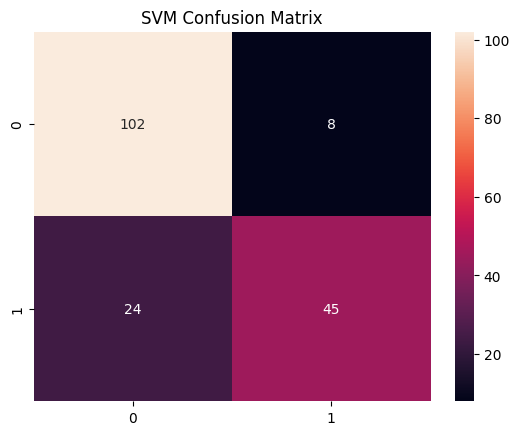

In [44]:
svm = SVC(probability=True)
evaluate_model(svm, X_train, X_test, y_train, y_test, "SVM")


KNN
Train Accuracy: 0.8553370786516854
Test Accuracy: 0.8212290502793296

Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



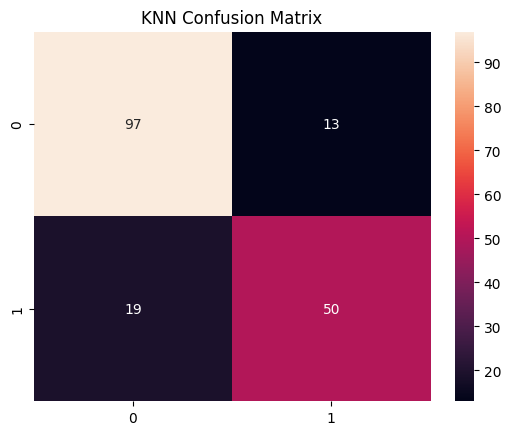

In [45]:
knn = KNeighborsClassifier(n_neighbors=5)
evaluate_model(knn, X_train, X_test, y_train, y_test, "KNN")

1. Logistic Regression works well among all of these models.
2. Random Forest Classifier Overfits the Model.
3. SVM recall is low.
4. KNN works fair.

**Build and Train Dense Neural Network**

In [ ]:
model = Sequential([
    #Takes input features and projects them into 64 different neurons
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    #Randomly turns off 30% of the neurons during each training so model don't overfit
    Dropout(0.3),
    #Compresses the 64 patterns down to 32 more complex representations to find deeper relationships b/w features
    Dense(32, activation='relu'),
    #Squeezes all 32 signals into a single number between 0 and 1 using the Sigmoid function
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(), tf.keras.metrics.Precision(), tf.keras.metrics.Recall()]
)

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                704       
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 1)                 33        
                                                                 
Total params: 2817 (11.00 KB)
Trainable params: 2817 (11.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [51]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [53]:
if not isinstance(X_train, np.ndarray):
    X_train = X_train.to_numpy()

if not isinstance(y_train, np.ndarray):
    y_train = y_train.to_numpy()

In [54]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100


18/18 [==============================] - 2s 23ms/step - loss: 0.6044 - accuracy: 0.7030 - auc_1: 0.7276 - precision_1: 0.7130 - recall_1: 0.3581 - val_loss: 0.5523 - val_accuracy: 0.7133 - val_auc_1: 0.8110 - val_precision_1: 0.6977 - val_recall_1: 0.5172
Epoch 2/100
18/18 [==============================] - 0s 4ms/step - loss: 0.5198 - accuracy: 0.7645 - auc_1: 0.8238 - precision_1: 0.7914 - recall_1: 0.5116 - val_loss: 0.5050 - val_accuracy: 0.7902 - val_auc_1: 0.8349 - val_precision_1: 0.7800 - val_recall_1: 0.6724
Epoch 3/100
18/18 [==============================] - 0s 4ms/step - loss: 0.4700 - accuracy: 0.8067 - auc_1: 0.8509 - precision_1: 0.8144 - recall_1: 0.6326 - val_loss: 0.4784 - val_accuracy: 0.7902 - val_auc_1: 0.8417 - val_precision_1: 0.7800 - val_recall_1: 0.6724
Epoch 4/100
18/18 [==============================] - 0s 5ms/step - loss: 0.4457 - accuracy: 0.8155 - auc_1: 0.8593 - precision_1: 0.7926 - recall_1: 0.6930 - val_loss: 0.4639 - val_accuracy: 0.790

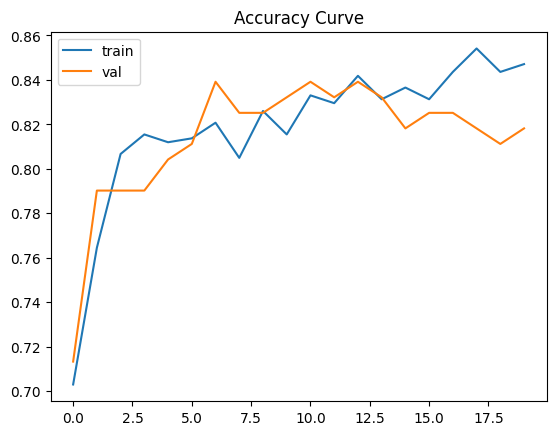

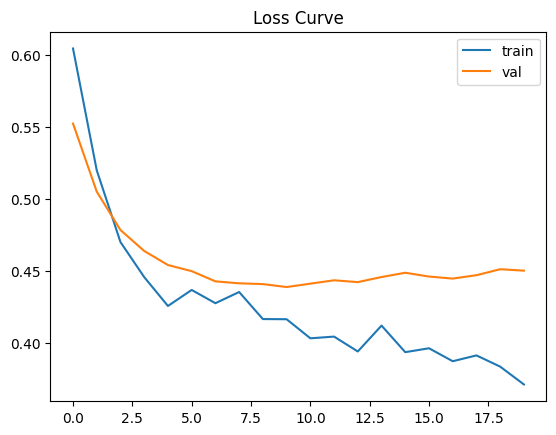

In [55]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Loss Curve")
plt.show()

In [56]:
y_pred_nn = (model.predict(X_test) > 0.5).astype(int)

print(classification_report(y_test, y_pred_nn))

6/6 [==============================] - 0s 2ms/step
              precision    recall  f1-score   support

           0       0.82      0.91      0.86       110
           1       0.82      0.68      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



6/6 [==============================] - 0s 1ms/step


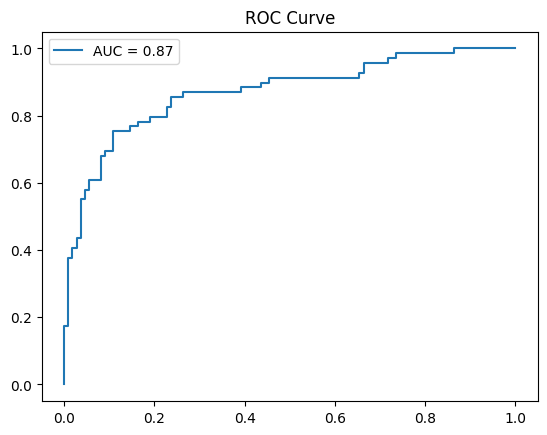

In [57]:
y_prob = model.predict(X_test)

fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.plot(fpr, tpr, label=f"AUC = {auc:.2f}")
plt.legend()
plt.title("ROC Curve")
plt.show()